<a href="https://colab.research.google.com/github/RuanSathler/Detectacao-de-FOG-com-Modelos-Leves-e-Generalizaveis-para-Classificacao-Inter-Paciente/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- CÉLULA 1: SETUP E VARIÁVEIS GLOBAIS ---
from google.colab import drive
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm # Barra de progresso

# 1. Montar o Drive
drive.mount('/content/drive')

# 2. Configurações de Caminho (VERIFIQUE SE ESTÁ CERTO)
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/PIBIC/treinamento/data'
SAVE_PATH = os.path.dirname(DATA_PATH) # Salva na pasta pai dos dados

# 3. Configurações do Experimento
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PACIENTES_TOTAIS = ['S01', 'S02', 'S03', 'S05', 'S06', 'S07', 'S08', 'S09']

# 4. Hiperparâmetros
FREQ_AMOSTRAGEM = 64
JANELA_SEGUNDOS = 4
WINDOW_SIZE = FREQ_AMOSTRAGEM * JANELA_SEGUNDOS # 256 pontos
STEP_SIZE = 64   # Overlap
BATCH_SIZE = 128
LEARNING_RATE = 0.001
EPOCHS = 100

print(f"✅ Ambiente configurado! Usando dispositivo: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Ambiente configurado! Usando dispositivo: cpu


In [ ]:
# --- CÉLULA 2: FUNÇÕES DE DADOS ---

def carregar_dados_brutos(pacientes_lista, path):
    colunas = ['Time', 'Ank_Hor_Fwd', 'Ank_Vert', 'Ank_Hor_Lat', 'Leg_Hor_Fwd',
               'Leg_Vert', 'Leg_Hor_Lat', 'Trunk_Hor_Fwd', 'Trunk_Vert', 'Trunk_Hor_Lat', 'Annotation']
    dados_totais = []

    for p in pacientes_lista:
        # Pega todos os arquivos do paciente (R01, R02...)
        arquivos = [f for f in os.listdir(path) if f.startswith(p) and f.endswith('.txt')]
        for arq in arquivos:
            caminho_arq = os.path.join(path, arq)
            try:
                df = pd.read_csv(caminho_arq, sep=' ', header=None, names=colunas)

                # Limpeza: Remove classe 0 e ajusta (1->0 Normal, 2->1 FoG)
                df = df[df['Annotation'] != 0].copy()
                df['Annotation'] = df['Annotation'].replace({1: 0, 2: 1})

                dados_totais.append(df)
            except Exception as e:
                print(f"Erro ao ler {arq}: {e}")

    if not dados_totais:
        return None

    return pd.concat(dados_totais, ignore_index=True)

def criar_janelas(df, window_size, step_size):
    X = []
    y = []

    # Extrai matrizes numpy para ser mais rápido
    features = df.iloc[:, 1:10].values
    labels = df.iloc[:, 10].values

    for i in range(0, len(df) - window_size, step_size):
        # Janela de dados (256 linhas, 9 sensores)
        janela_x = features[i : i + window_size]
        # Moda da etiqueta na janela
        label_moda = np.bincount(labels[i : i + window_size]).argmax()

        X.append(janela_x)
        y.append(label_moda)

    return np.array(X), np.array(y)

class DaphnetDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
# --- CÉLULA 3: ARQUITETURA DA CNN ---

class CNN_FOG(nn.Module):
    def __init__(self, input_dim=9, output_dim=2):
        super(CNN_FOG, self).__init__()

        # Bloco 1: Procura padrões simples
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2) # Reduz 256 -> 128
        self.dropout1 = nn.Dropout(0.2)

        # Bloco 2: Procura padrões complexos
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2) # Reduz 128 -> 64
        self.dropout2 = nn.Dropout(0.2)

        # Classificador
        # Entrada: 64 canais * 64 pontos de tempo restantes
        self.fc = nn.Linear(64 * 64, output_dim)

    def forward(self, x):
        # x entra como: (Batch, Tempo=256, Canais=9)
        # CNN quer:     (Batch, Canais=9, Tempo=256)
        x = x.permute(0, 2, 1)

        out = self.conv1(x)
        out = self.relu1(out)
        out = self.pool1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.relu2(out)
        out = self.pool2(out)
        out = self.dropout2(out)

        # Achatartudo para entrar na camada linear
        out = out.reshape(out.size(0), -1)

        out = self.fc(out)
        return out

In [ ]:
# --- CÉLULA 4 (FINAL V2): TREINAMENTO CNN COM GRÁFICOS DETALHADOS ---

def executar_cnn(paciente_teste):
    print(f"\n{'='*60}")
    print(f"🚀 INICIANDO CNN PARA PACIENTE: {paciente_teste}")
    print(f"{'='*60}")

    # 1. Preparar Dados
    pacientes_treino = [p for p in PACIENTES_TOTAIS if p != paciente_teste]

    # Treino
    df_train = carregar_dados_brutos(pacientes_treino, DATA_PATH)
    X_train, y_train = criar_janelas(df_train, WINDOW_SIZE, STEP_SIZE)
    train_loader = DataLoader(DaphnetDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    # Teste
    df_test = carregar_dados_brutos([paciente_teste], DATA_PATH)
    X_test, y_test = criar_janelas(df_test, WINDOW_SIZE, STEP_SIZE)
    test_loader = DataLoader(DaphnetDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

    # 2. Pesos (Balanceamento)
    n_normal = (y_train == 0).sum()
    n_fog = (y_train == 1).sum()
    peso_fog = n_normal / n_fog if n_fog > 0 else 1.0
    class_weights = torch.tensor([1.0, peso_fog], dtype=torch.float32).to(DEVICE)
    print(f"⚖️ Pesos definidos: Normal=1.0 | FoG={peso_fog:.2f}")

    # 3. Inicializar Modelo
    model = CNN_FOG(input_dim=9, output_dim=2).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Variáveis de monitoramento
    hist_test_acc = []
    hist_train_acc = [] # NOVO: Para guardar acurácia de treino
    hist_train_loss = []
    melhor_acc = 0.0
    melhor_epoca = 0

    # 4. Loop de Treino
    print(f"Iniciando {EPOCHS} épocas...")
    barra = tqdm(range(EPOCHS), desc="Treinando CNN", unit="ep")

    for epoch in barra:
        # --- FASE DE TREINO ---
        model.train()
        loss_acum = 0
        correct_train = 0
        total_train = 0

        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)

            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            loss_acum += loss.item()

            # Cálculo de acurácia de treino
            _, pred_train = torch.max(out, 1)
            total_train += y_b.size(0)
            correct_train += (pred_train == y_b).sum().item()

        # --- FASE DE AVALIAÇÃO (TESTE) ---
        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out = model(X_b)
                _, pred_test = torch.max(out, 1)
                total_test += y_b.size(0)
                correct_test += (pred_test == y_b).sum().item()

        # Cálculos finais da época
        acc_train = 100 * correct_train / total_train if total_train > 0 else 0
        acc_test = 100 * correct_test / total_test if total_test > 0 else 0
        avg_loss = loss_acum / len(train_loader)

        hist_train_acc.append(acc_train)
        hist_test_acc.append(acc_test)
        hist_train_loss.append(avg_loss)

        # Salvar o Melhor
        msg = ""
        if acc_test > melhor_acc:
            melhor_acc = acc_test
            melhor_epoca = epoch + 1
            path_save = os.path.join(SAVE_PATH, f'melhor_cnn_{paciente_teste}.pth')
            torch.save(model.state_dict(), path_save)
            msg = "💾 Recorde!"

        tqdm.write(f"Ep {epoch+1:02d} | Loss: {avg_loss:.4f} | Treino: {acc_train:.1f}% | Teste: {acc_test:.1f}% {msg}")

    # 5. Finalização
    print(f"\n🏆 MELHOR RESULTADO: {melhor_acc:.2f}% na época {melhor_epoca}")

    # --- PLOTAGEM DETALHADA (Igual ao da imagem de referência) ---
    plt.figure(figsize=(12, 5))

    # Gráfico 1: Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(hist_train_acc, label='Treino', color='tab:blue')
    plt.plot(hist_test_acc, label=f'Teste ({paciente_teste})', linestyle='--', color='tab:orange')
    # Marca o ponto da melhor época (melhor_epoca-1 porque o índice começa em 0)
    plt.plot(melhor_epoca-1, melhor_acc, 'go', label=f'Melhor ({melhor_acc:.1f}%)')
    plt.title(f'Acurácia - Testando em {paciente_teste}')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia (%)')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Gráfico 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist_train_loss, color='red')
    plt.title('Loss (Erro)')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model


🚀 INICIANDO CNN PARA PACIENTE: S01
⚖️ Pesos definidos: Normal=1.0 | FoG=6.28
Iniciando 100 épocas...


Treinando CNN:   1%|          | 1/100 [00:09<15:00,  9.10s/ep]

Ep 01 | Loss: 33.5604 | Treino: 58.1% | Teste: 70.1% 💾 Recorde!


Treinando CNN:   2%|▏         | 2/100 [00:16<12:47,  7.83s/ep]

Ep 02 | Loss: 1.1623 | Treino: 62.3% | Teste: 29.4% 


...

Ep 98 | Loss: 0.2416 | Treino: 90.1% | Teste: 67.5% 


Treinando CNN:  99%|█████████▉| 99/100 [12:06<00:07,  7.13s/ep]

Ep 99 | Loss: 0.2671 | Treino: 89.0% | Teste: 57.5% 


Treinando CNN: 100%|██████████| 100/100 [12:13<00:00,  7.34s/ep]


Ep 100 | Loss: 0.2505 | Treino: 89.1% | Teste: 71.3% 

🏆 MELHOR RESULTADO: 84.65% na época 64


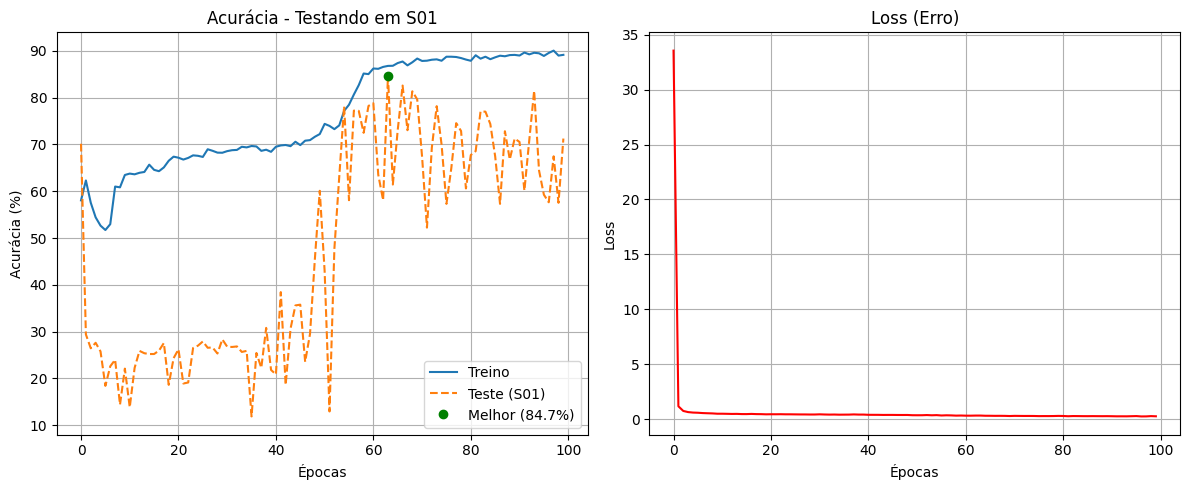

In [ ]:
modelo = executar_cnn('S01')


🚀 INICIANDO CNN PARA PACIENTE: S02
⚖️ Pesos definidos: Normal=1.0 | FoG=7.06
Iniciando 100 épocas...


Treinando CNN:   1%|          | 1/100 [00:08<13:47,  8.36s/ep]

Ep 01 | Loss: 15.7867 | Treino: 65.8% | Teste: 67.6% 💾 Recorde!


Treinando CNN:   2%|▏         | 2/100 [00:16<13:50,  8.47s/ep]

Ep 02 | Loss: 1.9157 | Treino: 72.0% | Teste: 65.8% 


...

Ep 98 | Loss: 0.2193 | Treino: 91.3% | Teste: 88.5% 


Treinando CNN:  99%|█████████▉| 99/100 [12:50<00:07,  7.42s/ep]

Ep 99 | Loss: 0.2241 | Treino: 90.7% | Teste: 88.6% 


Treinando CNN: 100%|██████████| 100/100 [12:58<00:00,  7.78s/ep]


Ep 100 | Loss: 0.2348 | Treino: 90.8% | Teste: 88.6% 

🏆 MELHOR RESULTADO: 90.20% na época 91


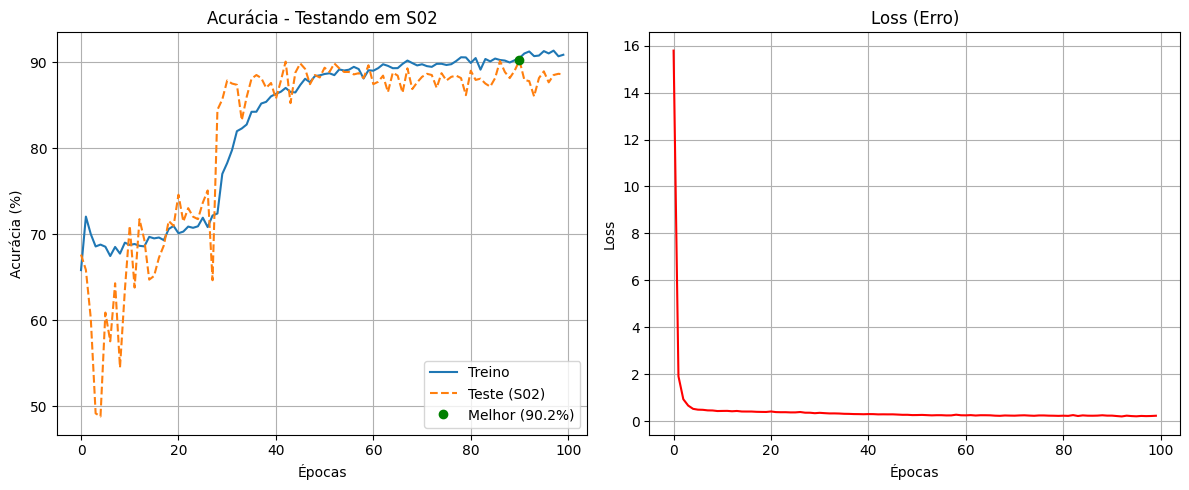

In [ ]:
modelo = executar_cnn('S02')


🚀 INICIANDO CNN PARA PACIENTE: S03
⚖️ Pesos definidos: Normal=1.0 | FoG=7.21
Iniciando 100 épocas...


Treinando CNN:   1%|          | 1/100 [00:09<14:57,  9.07s/ep]

Ep 01 | Loss: 28.1070 | Treino: 62.6% | Teste: 74.0% 💾 Recorde!


Treinando CNN:   2%|▏         | 2/100 [00:16<12:53,  7.90s/ep]

Ep 02 | Loss: 1.6105 | Treino: 72.8% | Teste: 73.2% 


...

Ep 98 | Loss: 0.1998 | Treino: 92.8% | Teste: 83.6% 


Treinando CNN:  99%|█████████▉| 99/100 [11:57<00:06,  6.91s/ep]

Ep 99 | Loss: 0.2155 | Treino: 92.8% | Teste: 83.8% 


Treinando CNN: 100%|██████████| 100/100 [12:04<00:00,  7.24s/ep]


Ep 100 | Loss: 0.1891 | Treino: 93.2% | Teste: 83.2% 

🏆 MELHOR RESULTADO: 87.34% na época 51


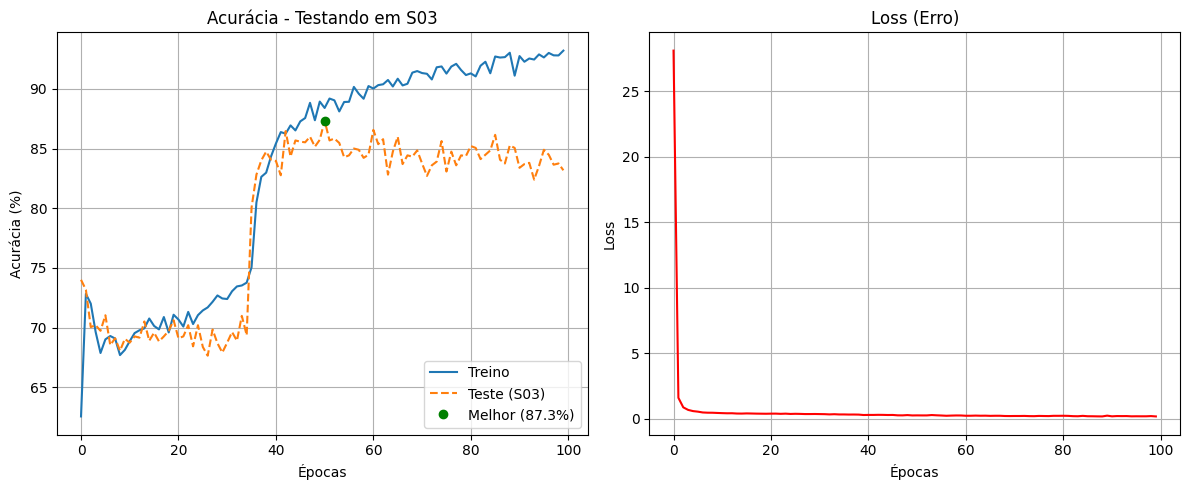

In [ ]:
modelo = executar_cnn('S03')


🚀 INICIANDO CNN PARA PACIENTE: S05
⚖️ Pesos definidos: Normal=1.0 | FoG=8.49
Iniciando 100 épocas...


Treinando CNN:   1%|          | 1/100 [00:08<13:23,  8.12s/ep]

Ep 01 | Loss: 15.0256 | Treino: 67.5% | Teste: 78.3% 💾 Recorde!


Treinando CNN:   2%|▏         | 2/100 [00:16<13:42,  8.39s/ep]

Ep 02 | Loss: 2.7691 | Treino: 76.4% | Teste: 80.1% 💾 Recorde!


...

Ep 98 | Loss: 0.1719 | Treino: 93.7% | Teste: 82.4% 


Treinando CNN:  99%|█████████▉| 99/100 [12:00<00:07,  7.04s/ep]

Ep 99 | Loss: 0.2307 | Treino: 91.5% | Teste: 82.8% 


Treinando CNN: 100%|██████████| 100/100 [12:06<00:00,  7.26s/ep]


Ep 100 | Loss: 0.1794 | Treino: 93.0% | Teste: 81.6% 

🏆 MELHOR RESULTADO: 84.28% na época 38


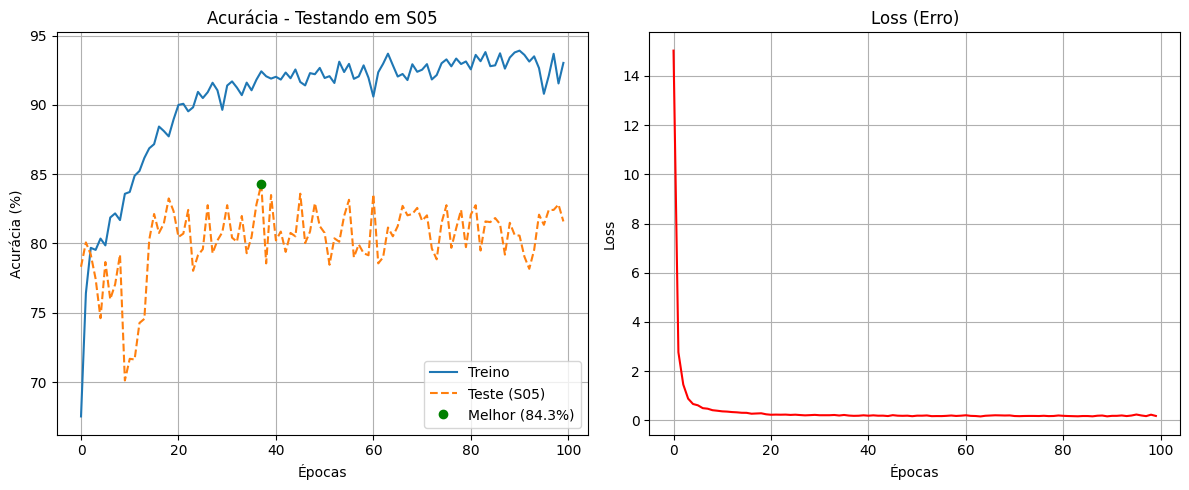

In [ ]:
modelo = executar_cnn('S05')


🚀 INICIANDO CNN PARA PACIENTE: S06
⚖️ Pesos definidos: Normal=1.0 | FoG=6.42
Iniciando 100 épocas...


Treinando CNN:   1%|          | 1/100 [00:08<13:54,  8.43s/ep]

Ep 01 | Loss: 20.1119 | Treino: 61.0% | Teste: 66.1% 💾 Recorde!


Treinando CNN:   2%|▏         | 2/100 [00:16<13:05,  8.01s/ep]

Ep 02 | Loss: 1.3831 | Treino: 69.0% | Teste: 44.0% 


...

Ep 98 | Loss: 0.2209 | Treino: 90.5% | Teste: 87.3% 


Treinando CNN:  99%|█████████▉| 99/100 [12:18<00:07,  7.49s/ep]

Ep 99 | Loss: 0.2120 | Treino: 90.9% | Teste: 89.6% 


Treinando CNN: 100%|██████████| 100/100 [12:25<00:00,  7.46s/ep]


Ep 100 | Loss: 0.2213 | Treino: 90.7% | Teste: 75.1% 

🏆 MELHOR RESULTADO: 92.14% na época 45


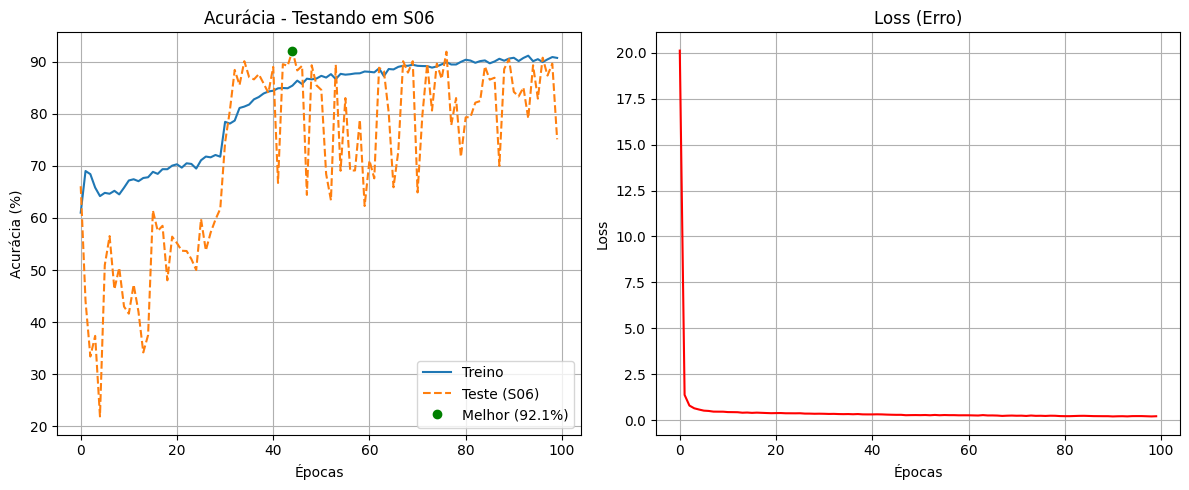

In [ ]:
modelo = executar_cnn('S06')


🚀 INICIANDO CNN PARA PACIENTE: S07
⚖️ Pesos definidos: Normal=1.0 | FoG=6.39
Iniciando 100 épocas...


Treinando CNN:   1%|          | 1/100 [00:09<15:11,  9.20s/ep]

Ep 01 | Loss: 21.3994 | Treino: 64.6% | Teste: 50.0% 💾 Recorde!


Treinando CNN:   2%|▏         | 2/100 [00:16<13:33,  8.30s/ep]

Ep 02 | Loss: 1.5994 | Treino: 73.1% | Teste: 40.5% 


...

Ep 98 | Loss: 0.2199 | Treino: 91.0% | Teste: 81.3% 


Treinando CNN:  99%|█████████▉| 99/100 [12:49<00:07,  7.48s/ep]

Ep 99 | Loss: 0.2151 | Treino: 91.5% | Teste: 86.2% 


Treinando CNN: 100%|██████████| 100/100 [12:56<00:00,  7.77s/ep]


Ep 100 | Loss: 0.2242 | Treino: 90.9% | Teste: 90.4% 

🏆 MELHOR RESULTADO: 94.66% na época 54


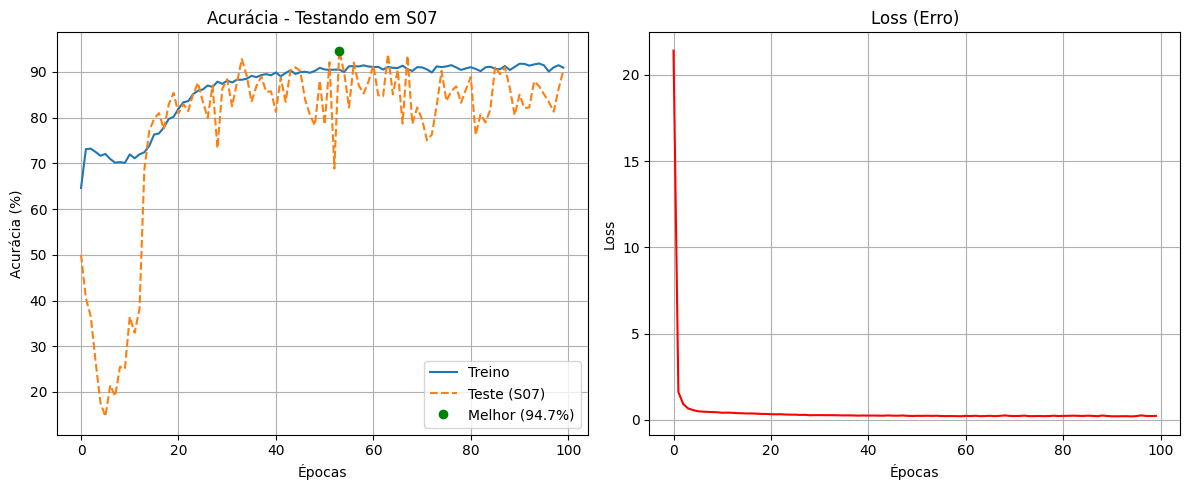

In [ ]:
modelo = executar_cnn('S07')


🚀 INICIANDO CNN PARA PACIENTE: S08
⚖️ Pesos definidos: Normal=1.0 | FoG=7.58
Iniciando 100 épocas...


Treinando CNN:   1%|          | 1/100 [00:09<15:53,  9.63s/ep]

Ep 01 | Loss: 24.0373 | Treino: 64.6% | Teste: 33.6% 💾 Recorde!


Treinando CNN:   2%|▏         | 2/100 [00:18<14:59,  9.18s/ep]

Ep 02 | Loss: 1.8551 | Treino: 72.4% | Teste: 27.7% 


...

Ep 98 | Loss: 0.1996 | Treino: 91.4% | Teste: 69.4% 


Treinando CNN:  99%|█████████▉| 99/100 [13:20<00:07,  7.93s/ep]

Ep 99 | Loss: 0.1814 | Treino: 92.5% | Teste: 79.1% 


Treinando CNN: 100%|██████████| 100/100 [13:27<00:00,  8.07s/ep]


Ep 100 | Loss: 0.1900 | Treino: 91.8% | Teste: 77.5% 

🏆 MELHOR RESULTADO: 82.81% na época 94


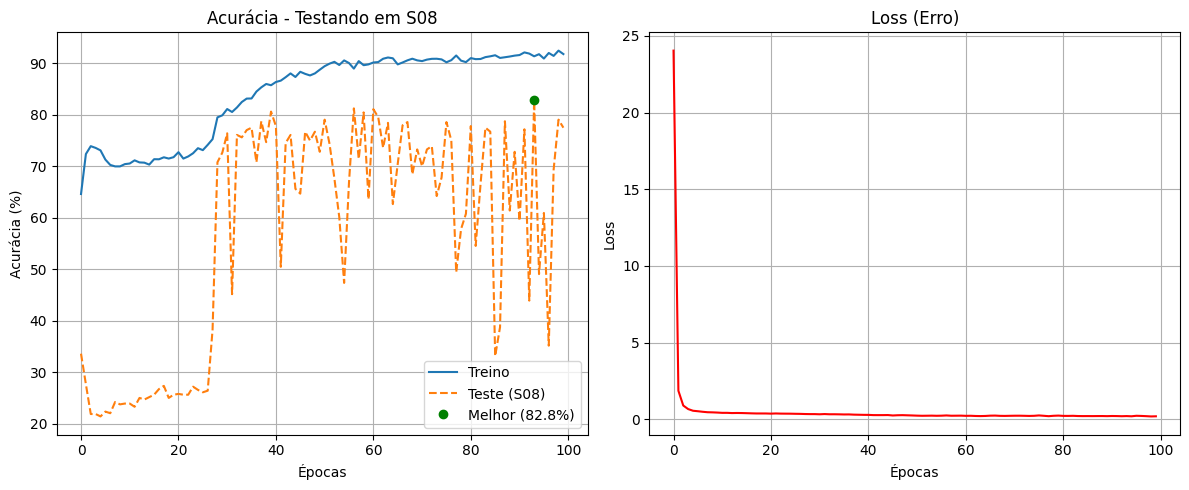

In [ ]:
modelo = executar_cnn('S08')


🚀 INICIANDO CNN PARA PACIENTE: S09
⚖️ Pesos definidos: Normal=1.0 | FoG=7.26
Iniciando 100 épocas...


Treinando CNN:   1%|          | 1/100 [00:08<14:17,  8.66s/ep]

Ep 01 | Loss: 20.9497 | Treino: 62.7% | Teste: 78.2% 💾 Recorde!


Treinando CNN:   2%|▏         | 2/100 [00:17<14:09,  8.67s/ep]

Ep 02 | Loss: 1.7732 | Treino: 69.6% | Teste: 80.5% 💾 Recorde!


...

Ep 98 | Loss: 0.2450 | Treino: 91.1% | Teste: 89.2% 


Treinando CNN:  99%|█████████▉| 99/100 [12:27<00:07,  7.17s/ep]

Ep 99 | Loss: 0.2409 | Treino: 91.3% | Teste: 87.7% 


Treinando CNN: 100%|██████████| 100/100 [12:35<00:00,  7.55s/ep]


Ep 100 | Loss: 0.2233 | Treino: 91.5% | Teste: 88.1% 

🏆 MELHOR RESULTADO: 92.97% na época 54


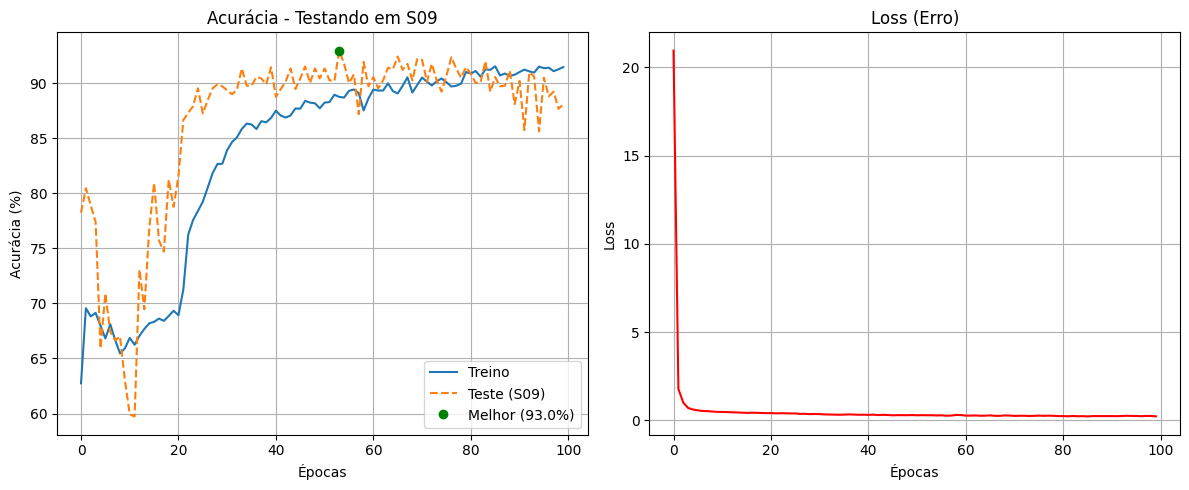

In [ ]:
modelo = executar_cnn('S09')